# ___Phylogenetics___
------------------

In [1]:
!python --version

Python 3.14.0


The system cannot find the path specified.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
subset_taxa = pd.read_csv(r"../../data/chapter2/FREDv3subset/FRED_subset_unique_taxa.csv")

In [4]:
subset_taxa

,F01286,F01287,F01289,F01290
0,Populus,trichocarpa,Salicaceae,Malpighiales
1,Populus,tremula,Salicaceae,Malpighiales
2,Altingia,obovata,Altingiaceae,Saxifragales
3,Cryptocarya,chinensis,Lauraceae,Laurales
4,Elaeocarpus,sylvestris,Elaeocarpaceae,Oxalidales
...,...,...,...,...
198,Quercus,alba,Fagaceae,Fagales
199,Quercus,rubra,Fagaceae,Fagales
200,Pleioblastus,amarus,Poaceae,Poales
201,Nyssa,aquatica,Cornaceae,Cornales


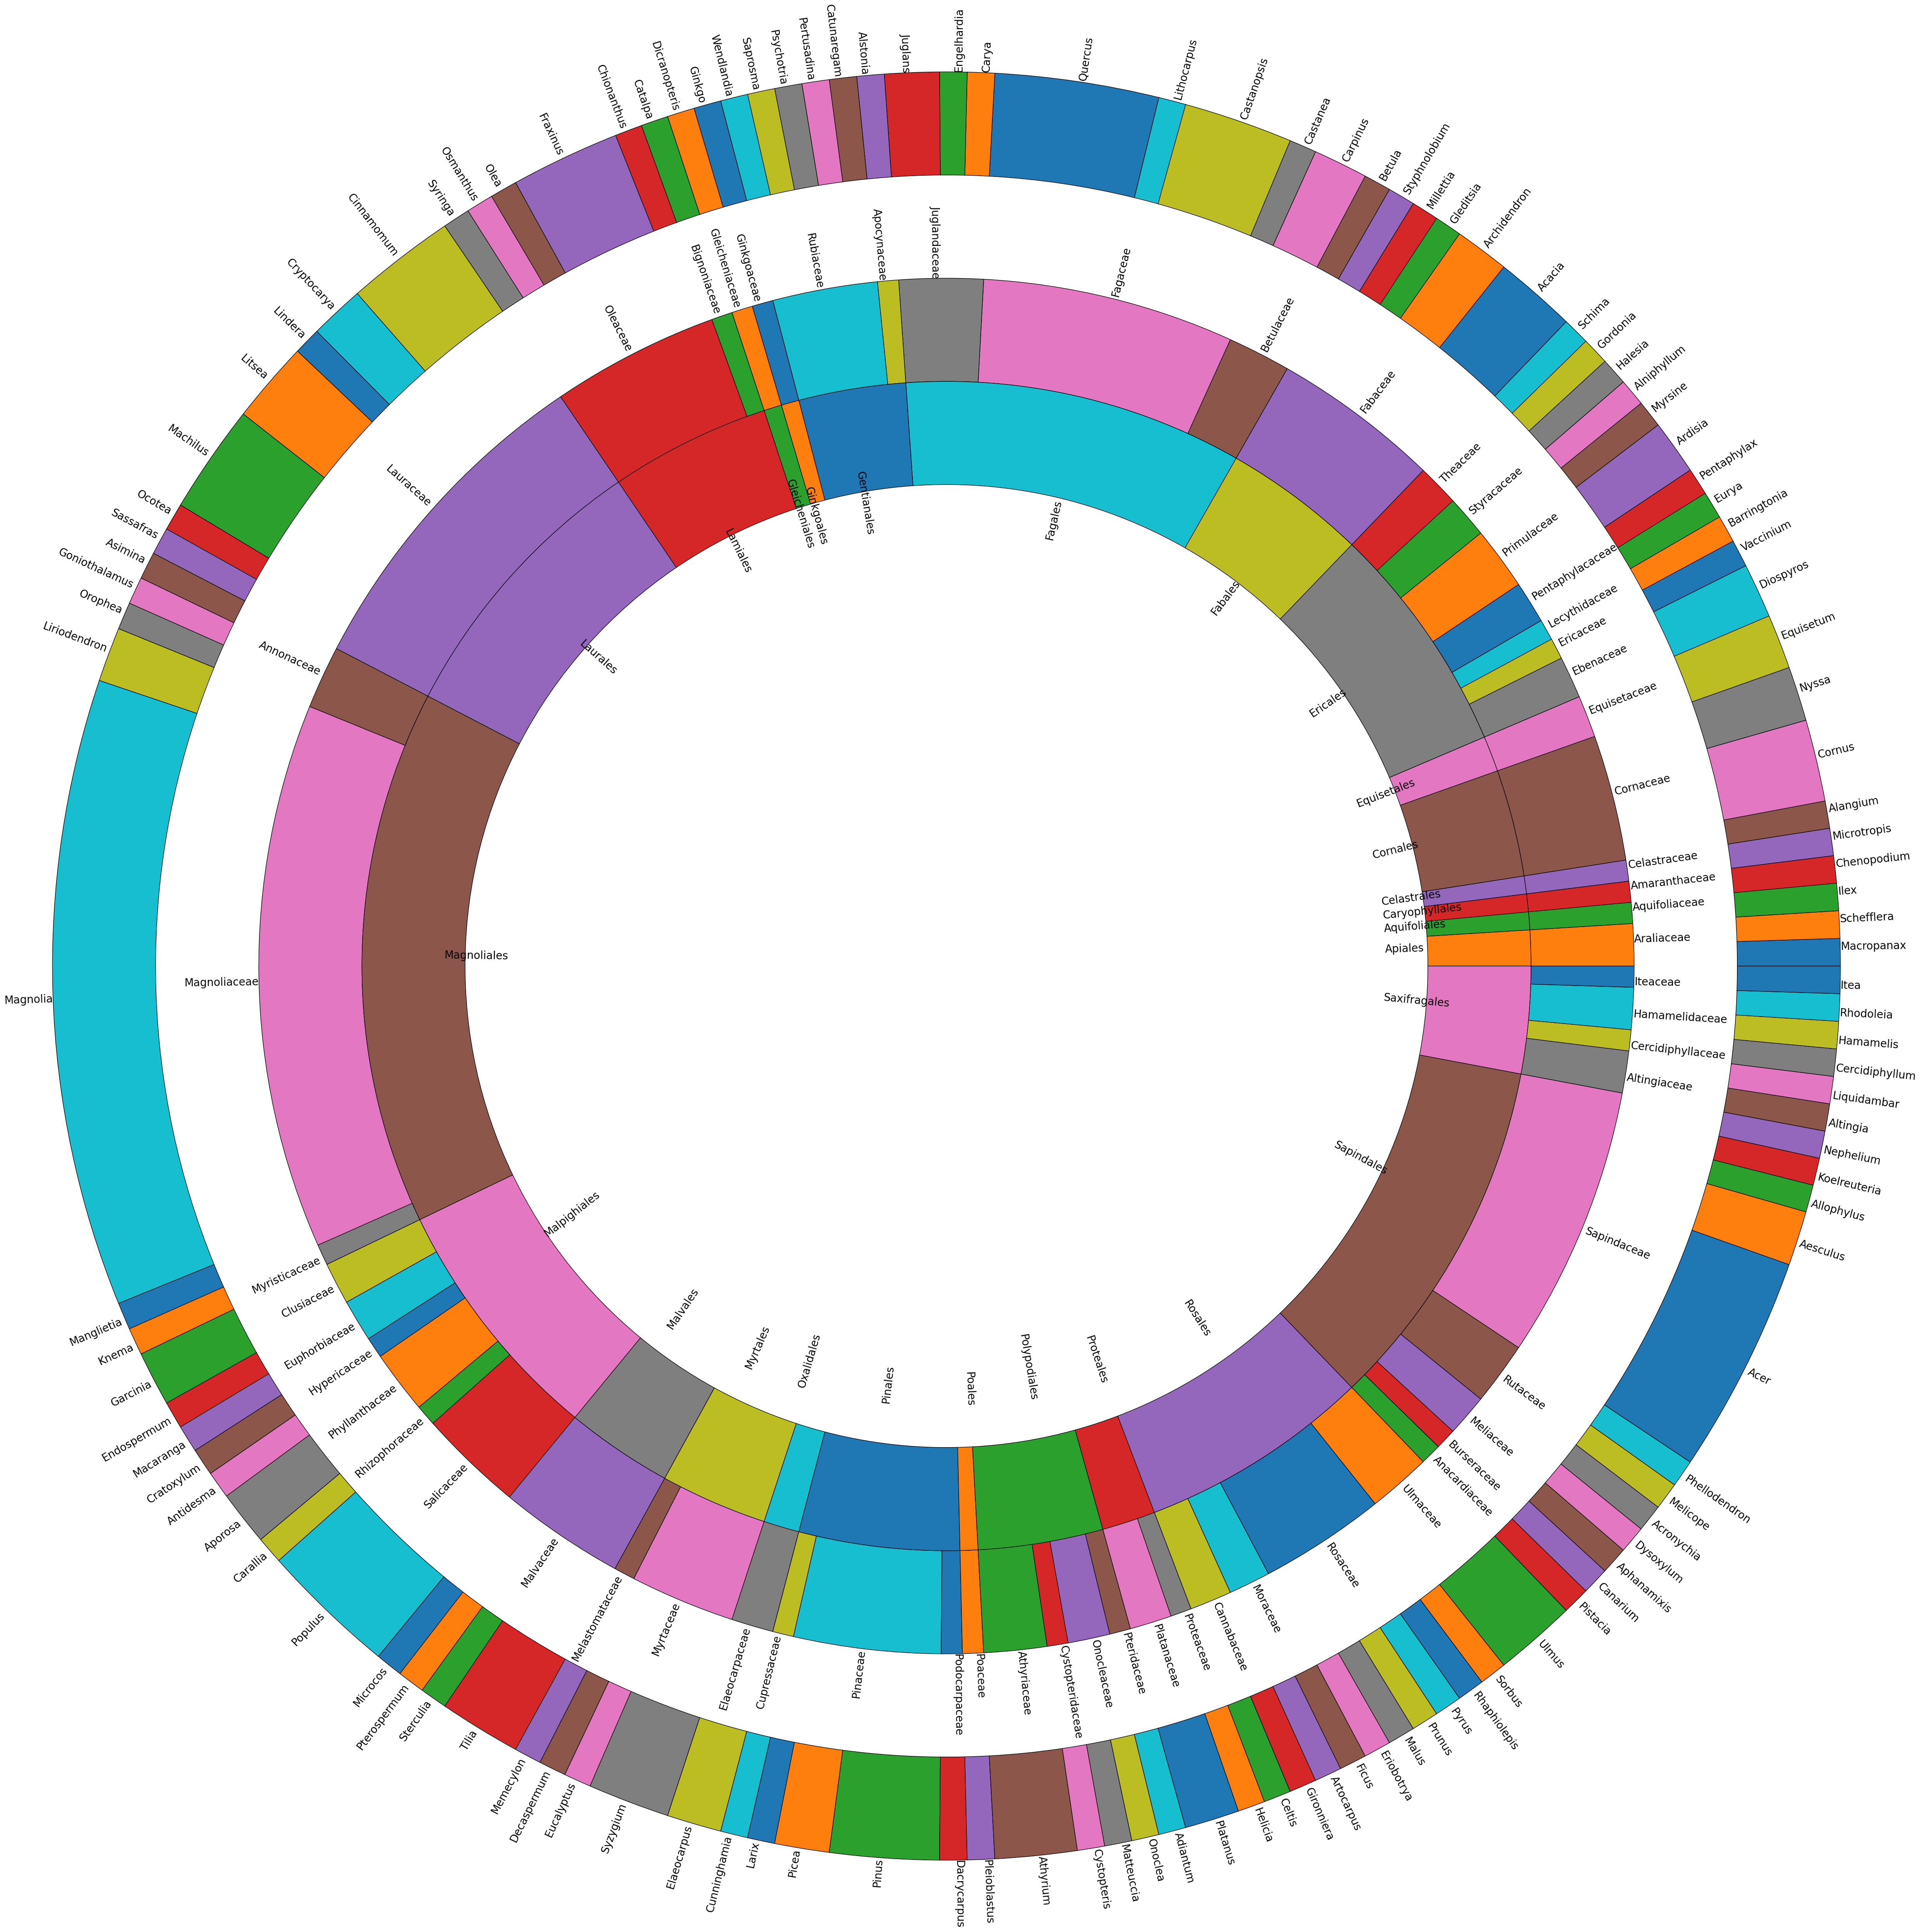

In [10]:
# PIE CHART FOR TAXONOMIC DIVERSITY - BAND WIDTHS REPRESENT NUMBER OF UNIQUE TAXA NOT NUMBER OF TRAIT RECORDS!!!!!

fig, axes = plt.subplots()
fig.set_size_inches(50, 50)
plt.rcParams["font.size"] = 20

RADIUS = 1.00
WIDTH = 0.15
WEDGEPROPERTIES = {
    "width": WIDTH,
    "edgecolor": "black"
}

taxonomically_sorted_data = subset_taxa.sort_values(["F01290", "F01289", "F01286"])

# genera
axes.pie(x=taxonomically_sorted_data.F01286.value_counts(sort=False).values,
         labels=taxonomically_sorted_data.F01286.value_counts(sort=False).index, # autopct='%1.2f%%', pctdistance=0.5,
         labeldistance=1.0, radius=RADIUS+2*WIDTH, wedgeprops=WEDGEPROPERTIES, rotatelabels=True,
         startangle=0
        )

# family
axes.pie(x=taxonomically_sorted_data.F01289.value_counts(sort=False).values,
         labels=taxonomically_sorted_data.F01289.value_counts(sort=False).index, # autopct='%1.2f%%', pctdistance=0.5,
         labeldistance=1.0, radius=RADIUS, wedgeprops=WEDGEPROPERTIES, rotatelabels=True,
         startangle=0
        )

# order
axes.pie(x=taxonomically_sorted_data.F01290.value_counts(sort=False).values,
         labels=taxonomically_sorted_data.F01290.value_counts(sort=False).index, # autopct='%1.2f%%', pctdistance=0.5,
         labeldistance=0.75, radius=RADIUS-WIDTH, wedgeprops=WEDGEPROPERTIES, rotatelabels=True,
         startangle=0, textprops={"va":"baseline"}
        )

axes.set_aspect("equal")
plt.tight_layout()
# plt.show()
plt.savefig(fname=r"../../plots/fred_subset_taxonomic_diversity.png", format="png", dpi=100, transparent=True, bbox_inches="tight")

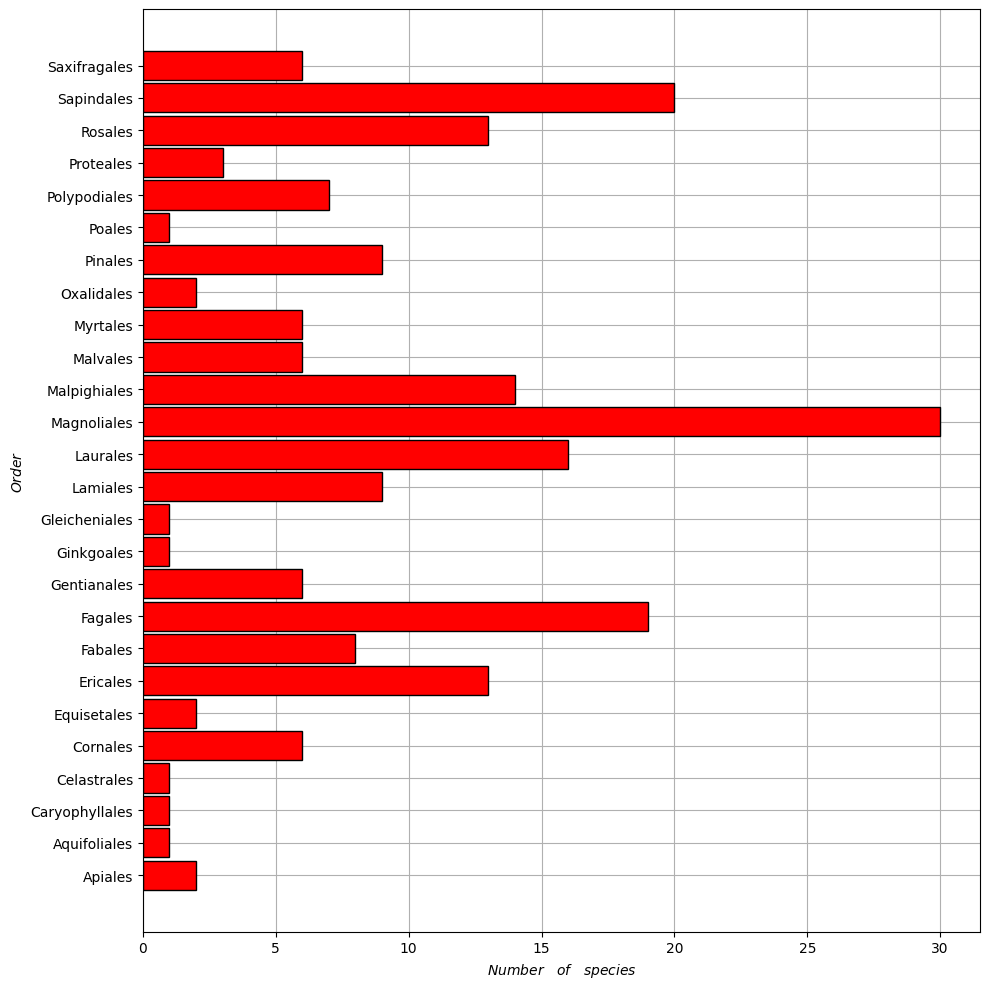

In [30]:
fig, axes = plt.subplots()
fig.set_size_inches(10, 10)
axes.barh(y=subset_taxa.F01290.sort_values().unique(), width=subset_taxa.F01290.sort_values().value_counts(sort=False), height=0.90, color="red", edgecolor="black")
axes.grid()
axes.set_axisbelow(True)
axes.set_xlabel(r"$Number\hspace{1}of\hspace{1}species$")
axes.set_ylabel(r"$Order$")
plt.tight_layout()
plt.show()
# plt.savefig(fname=r"../../plots/fredv3subset_orders.png", dpi=500, transparent=True)

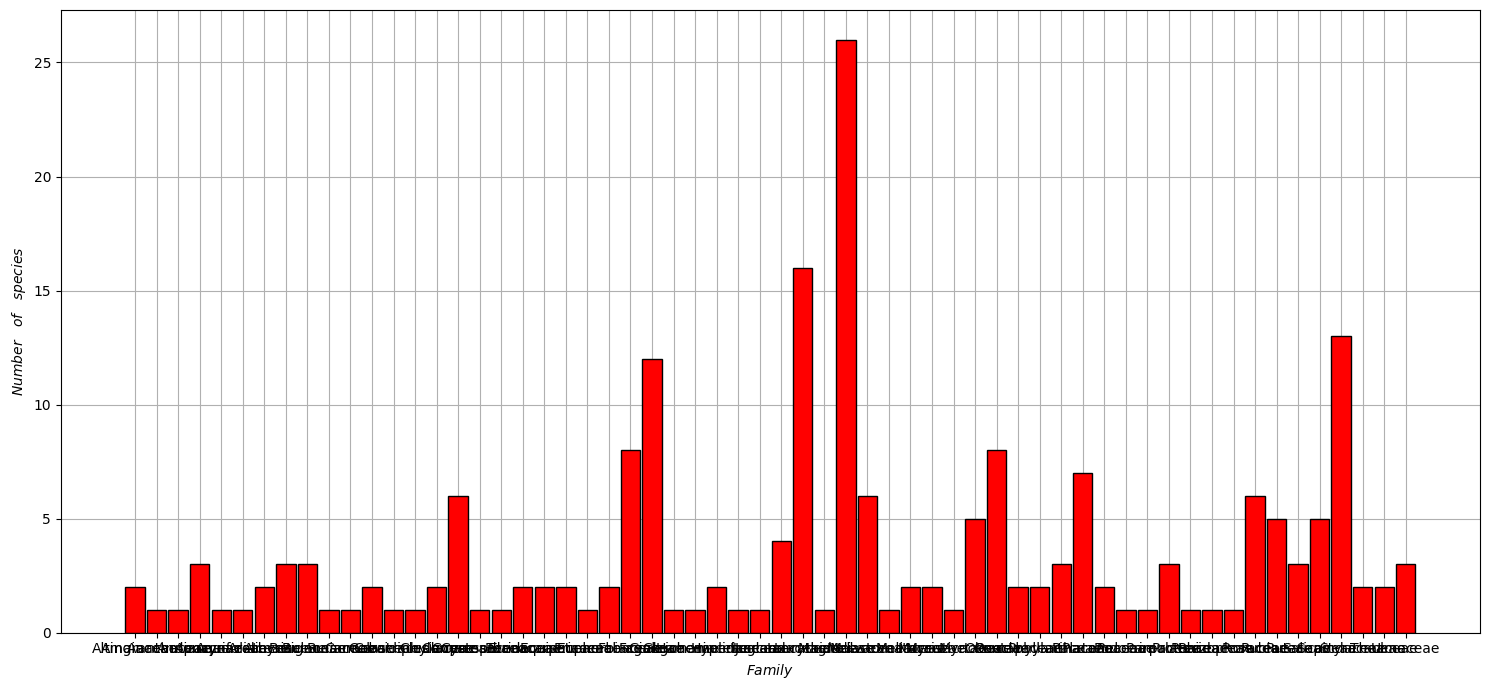

In [5]:
fig, axes = plt.subplots()
fig.set_size_inches(15, 7)
axes.bar(x=subset_taxa.F01289.sort_values().unique(), height=subset_taxa.F01289.sort_values().value_counts(sort=False), width=0.90, color="red", edgecolor="black")
axes.grid()
axes.set_axisbelow(True)
axes.set_xlabel(r"$Family$")
axes.set_ylabel(r"$Number\hspace{1}of\hspace{1}species$")
plt.tight_layout()
plt.show()
# plt.savefig(fname=r"../../plots/fredv3subset_families.png", dpi=500, transparent=True)

In [9]:
plantlookup = pd.read_csv(r"../../data/chapter2/plant_lookup.csv", encoding="latin1", low_memory=False)

In [18]:
plantlookup.loc[:, ["number.of.accepted.species", "order"]].groupby("order").sum().query("order.isin(@subset_taxa.F01290.unique())")

,number.of.accepted.species
order,
Apiales,4967
Aquifoliales,606
Caryophyllales,12452
Celastrales,1170
Cornales,692
Equisetales,20
Ericales,11270
Fabales,25660
Fagales,1397


In [17]:
subset_taxa.F01290.unique()

array(['Malpighiales', 'Saxifragales', 'Laurales', 'Oxalidales',
       'Lamiales', 'Sapindales', 'Fagales', 'Malvales', 'Magnoliales',
       'Cornales', 'Ericales', 'Fabales', 'Aquifoliales', 'Proteales',
       'Rosales', 'Myrtales', 'Celastrales', 'Gentianales', 'Apiales',
       'Polypodiales', 'Equisetales', 'Caryophyllales', 'Ginkgoales',
       'Pinales', 'Gleicheniales', 'Poales'], dtype=object)